# Mask Alignment Visualisation
Compares:
1. WSI thumbnail at the mask level
2. GeoJSON annotations drawn directly on the thumbnail (ground truth)
3. Produced mask PNG overlaid on the thumbnail

In [1]:
import json
from pathlib import Path
import numpy as np
import openslide
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
# Resolved exactly the way tools/extract_masks.py resolves them, so this
# notebook and the script whose output it checks cannot disagree about where
# the cohort or the masks live. Override with $DP_HSI_BC_ROOT / $DP_SCRATCH_ROOT.
#
# All three literals replaced here were stale as well as machine-specific: two
# named a `PKG - `-prefixed cohort directory that has never existed on this
# machine (the cohort is `.datasets/HistologyHSI-BC-Recurrence/`, which is what
# tools/hsi_bc/ already uses), and the third named `.scratch/datasets/masks`,
# which nothing else in the repository refers to.
from dpcode.paths import resolve_paths
from tools.extract_masks import ANNOTATION_SUBDIR, IMAGE_SUBDIR

_paths       = resolve_paths()
COHORT_ROOT  = Path(_paths['hsi_bc_root'])
WSI_DIR      = COHORT_ROOT / IMAGE_SUBDIR
GEOJSON_DIR  = COHORT_ROOT / ANNOTATION_SUBDIR
MASK_DIR     = Path(_paths['scratch_root']) / 'hsi_bc' / 'masks'   # extract_masks.py --mask_dir default

# Change this to any slide ID present in the dataset
SLIDE_ID  = '90'
MASK_LEVEL = 6   # must match the level used in extract_masks.py

CARCINOMA_CLASSES = {'in situ carcinoma', 'infiltrant carcinoma'}
CLASS_COLORS = {
    'in situ carcinoma':   (255,   0,   0, 160),   # red
    'infiltrant carcinoma':(255, 165,   0, 160),   # orange
    'normal tissue':       (  0, 255,   0, 160),   # green
}

In [3]:
wsi_path     = WSI_DIR     / f'{SLIDE_ID}.mrxs'
geojson_path = GEOJSON_DIR / f'{SLIDE_ID}.geojson'
mask_path    = MASK_DIR    / f'{SLIDE_ID}_mask.png'

assert wsi_path.exists(),     f'WSI not found: {wsi_path}'
assert geojson_path.exists(), f'GeoJSON not found: {geojson_path}'
assert mask_path.exists(),    f'Mask PNG not found: {mask_path}  — run extract_masks.py first'

In [4]:
# ── Load WSI thumbnail at mask level ─────────────────────────────────────────
wsi = openslide.OpenSlide(str(wsi_path))
w, h = wsi.level_dimensions[MASK_LEVEL]
thumbnail = wsi.read_region((0, 0), MASK_LEVEL, (w, h)).convert('RGB')
downsample = wsi.level_downsamples[MASK_LEVEL]
print(f'Thumbnail size: {w} x {h}  (downsample x{downsample:.0f})')

Thumbnail size: 1372 x 3104  (downsample x64)


In [5]:
# ── Helper: scale GeoJSON coords to mask level ───────────────────────────────
def scale_coords(coords, downsample):
    return [(int(x / downsample), int(y / downsample)) for x, y in coords]

def get_polygon_coords(feature):
    geom = feature['geometry']
    if geom['type'] == 'Polygon':
        return [geom['coordinates'][0]]
    elif geom['type'] == 'MultiPolygon':
        return [ring[0] for ring in geom['coordinates']]
    return []

with open(geojson_path) as f:
    geojson = json.load(f)

# Count by class
from collections import Counter
counts = Counter(feat['properties']['classification']['name'] for feat in geojson['features'])
print('Annotation counts:', dict(counts))

Annotation counts: {'normal tissue': 8, 'infiltrant carcinoma': 1}


In [6]:
# ── Build GeoJSON overlay (all classes colour-coded) ─────────────────────────
geojson_overlay = Image.new('RGBA', (w, h), (0, 0, 0, 0))
draw_gj = ImageDraw.Draw(geojson_overlay)

for feat in geojson['features']:
    cls   = feat.get('properties', {}).get('classification', {}).get('name', '')
    color = CLASS_COLORS.get(cls, (128, 128, 128, 160))
    for ring in get_polygon_coords(feat):
        pts = scale_coords(ring, downsample)
        draw_gj.polygon(pts, fill=color, outline=(*color[:3], 255))

geojson_vis = Image.alpha_composite(thumbnail.convert('RGBA'), geojson_overlay).convert('RGB')

In [7]:
# ── Build produced-mask overlay (carcinoma only) ─────────────────────────────
mask_png = Image.open(mask_path).convert('L')
assert mask_png.size == (w, h), f'Size mismatch: mask {mask_png.size} vs thumbnail {(w,h)}'

mask_rgba = np.zeros((h, w, 4), dtype=np.uint8)
mask_arr  = np.array(mask_png)
mask_rgba[mask_arr > 0] = [255, 0, 0, 160]   # red where mask is white

mask_overlay = Image.fromarray(mask_rgba, 'RGBA')
mask_vis     = Image.alpha_composite(thumbnail.convert('RGBA'), mask_overlay).convert('RGB')

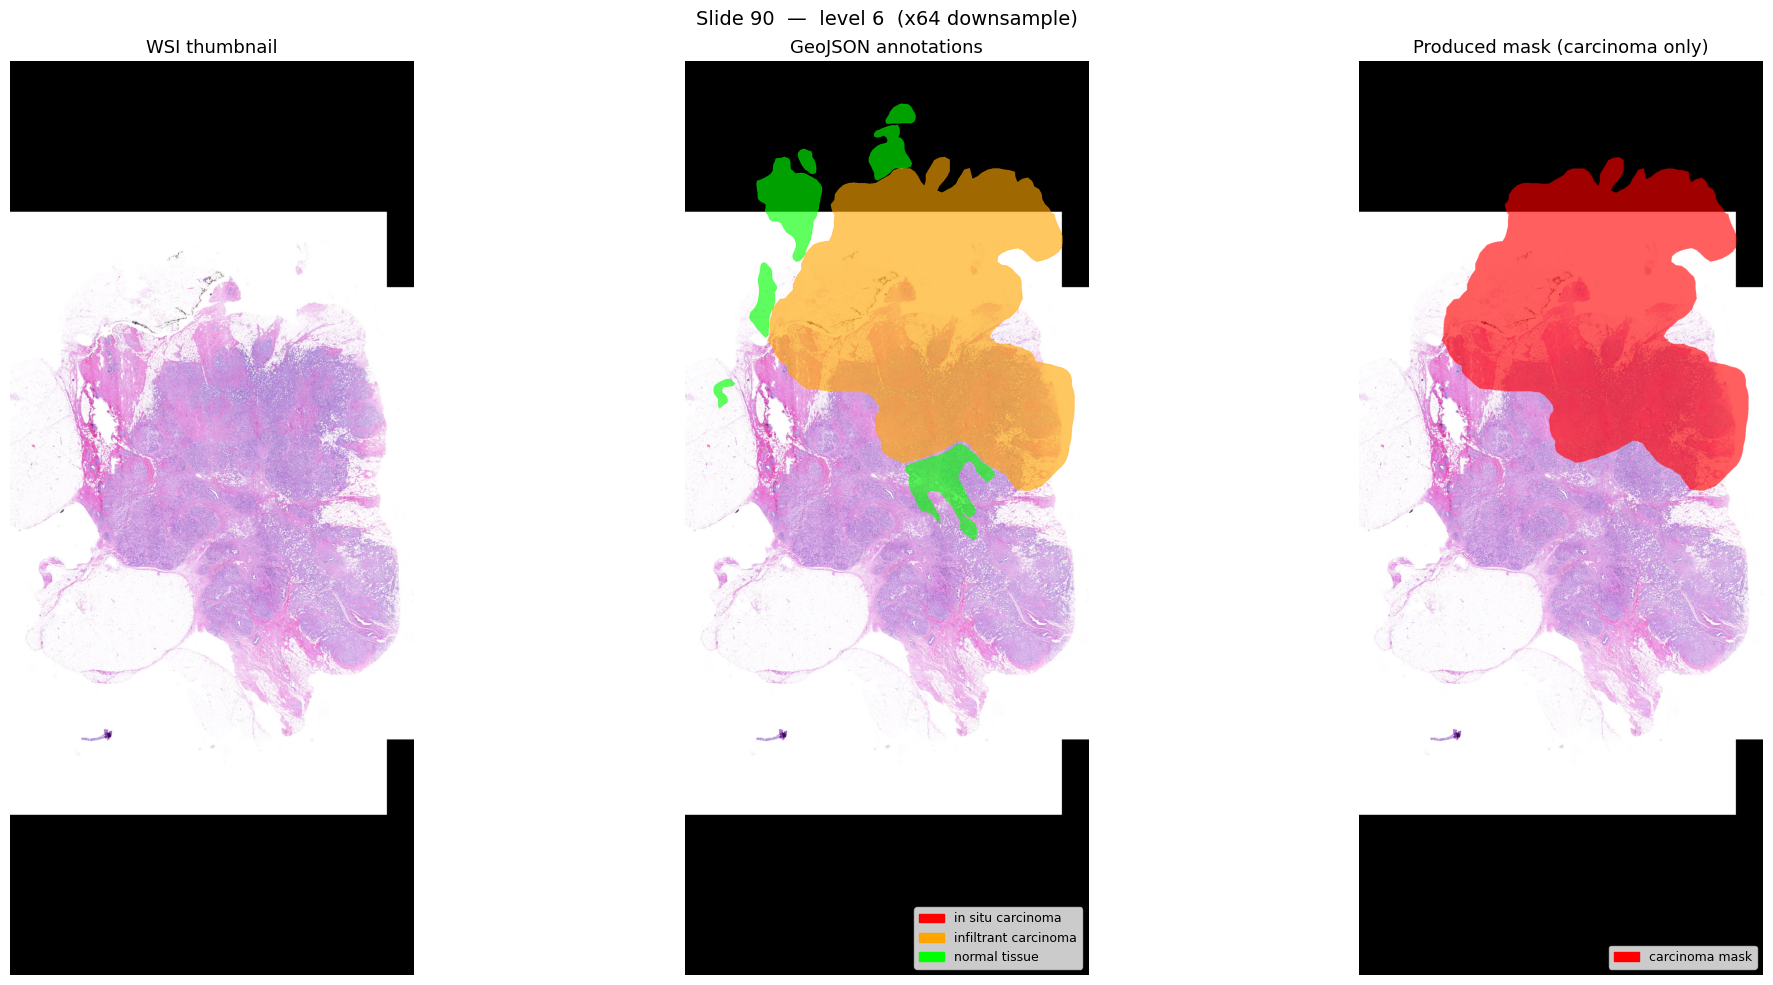

In [8]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

axes[0].imshow(thumbnail)
axes[0].set_title('WSI thumbnail', fontsize=13)

axes[1].imshow(geojson_vis)
axes[1].set_title('GeoJSON annotations', fontsize=13)
legend_patches = [mpatches.Patch(color=np.array(c[:3])/255, label=n)
                  for n, c in CLASS_COLORS.items()]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)

axes[2].imshow(mask_vis)
axes[2].set_title('Produced mask (carcinoma only)', fontsize=13)
axes[2].legend(handles=[mpatches.Patch(color='red', label='carcinoma mask')],
               loc='lower right', fontsize=9)

for ax in axes:
    ax.axis('off')

plt.suptitle(f'Slide {SLIDE_ID}  —  level {MASK_LEVEL}  (x{downsample:.0f} downsample)', fontsize=14)
plt.tight_layout()
plt.show()

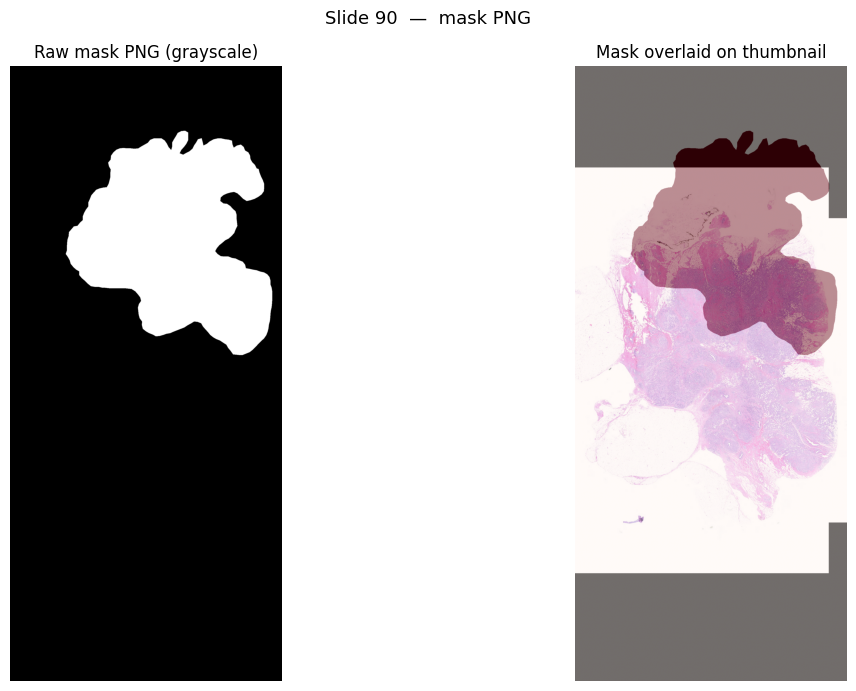

In [9]:
# ── Side-by-side: raw mask PNG ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(mask_png, cmap='gray')
axes[0].set_title('Raw mask PNG (grayscale)', fontsize=12)
axes[1].imshow(thumbnail)
axes[1].imshow(mask_png, cmap='Reds', alpha=0.45)
axes[1].set_title('Mask overlaid on thumbnail', fontsize=12)
for ax in axes:
    ax.axis('off')
plt.suptitle(f'Slide {SLIDE_ID}  —  mask PNG', fontsize=13)
plt.tight_layout()
plt.show()

wsi.close()

In [10]:
# ── (Optional) Loop over all available slides ─────────────────────────────────
# Uncomment to batch-preview all processed slides

# slide_ids = [p.stem for p in MASK_DIR.glob('*_mask.png')]
# for sid in sorted(slide_ids):
#     SLIDE_ID = sid.replace('_mask', '')
#     # re-run the cells above with this SLIDE_ID, or call a helper function